In [144]:
import pandas as pd
from matplotlib.ticker import PercentFormatter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
import sys
import platform
import importlib

In [145]:
verim03 = "../data/heart.csv"
p3heart = pd.read_csv(verim03)

In [146]:
p3heart.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [147]:
p3heart.rename(columns={
    'Age': 'yas',
    'Sex': 'cinsiyet',
    'ChestPainType': 'gogus_agrisi_tipi',
    'RestingBP': 'dinlenme_tansiyonu',
    'Cholesterol': 'kolesterol',
    'FastingBS': 'aclik_kan_sekeri',
    'RestingECG': 'ekg_sonucu',
    'MaxHR': 'maks_nabiz',
    'ExerciseAngina': 'gogus_agrisi',
    'Oldpeak': 'oldpeak',
    'ST_Slope': 'st_yamasi',
    'HeartDisease': 'kalp_hastaligi'
}, inplace=True)

Eğitim amaçlı projeler yaptığım için anlaşılması adı adına her projelerde sütun isimlerini dilimize çeviriyorum.

In [148]:
p3heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   yas                 918 non-null    int64  
 1   cinsiyet            918 non-null    object 
 2   gogus_agrisi_tipi   918 non-null    object 
 3   dinlenme_tansiyonu  918 non-null    int64  
 4   kolesterol          918 non-null    int64  
 5   aclik_kan_sekeri    918 non-null    int64  
 6   ekg_sonucu          918 non-null    object 
 7   maks_nabiz          918 non-null    int64  
 8   gogus_agrisi        918 non-null    object 
 9   oldpeak             918 non-null    float64
 10  st_yamasi           918 non-null    object 
 11  kalp_hastaligi      918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Eksiksiz veri mükemmel

In [149]:
p3heart.isnull().sum()

yas                   0
cinsiyet              0
gogus_agrisi_tipi     0
dinlenme_tansiyonu    0
kolesterol            0
aclik_kan_sekeri      0
ekg_sonucu            0
maks_nabiz            0
gogus_agrisi          0
oldpeak               0
st_yamasi             0
kalp_hastaligi        0
dtype: int64

In [150]:
sütunlar = list(p3heart.columns)
sütunlar

['yas',
 'cinsiyet',
 'gogus_agrisi_tipi',
 'dinlenme_tansiyonu',
 'kolesterol',
 'aclik_kan_sekeri',
 'ekg_sonucu',
 'maks_nabiz',
 'gogus_agrisi',
 'oldpeak',
 'st_yamasi',
 'kalp_hastaligi']

In [151]:
p3heart.head()

,yas,cinsiyet,gogus_agrisi_tipi,dinlenme_tansiyonu,kolesterol,aclik_kan_sekeri,ekg_sonucu,maks_nabiz,gogus_agrisi,oldpeak,st_yamasi,kalp_hastaligi
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [152]:
p3heart.describe().T

,count,mean,std,min,25%,50%,75%,max
yas,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
dinlenme_tansiyonu,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
kolesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
aclik_kan_sekeri,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
maks_nabiz,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
kalp_hastaligi,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


Sayısal sütunların istatistiksel özeti

Tekrarlanan satır yok

In [153]:
p3heart.nunique()

yas                    50
cinsiyet                2
gogus_agrisi_tipi       4
dinlenme_tansiyonu     67
kolesterol            222
aclik_kan_sekeri        2
ekg_sonucu              3
maks_nabiz            119
gogus_agrisi            2
oldpeak                53
st_yamasi               3
kalp_hastaligi          2
dtype: int64

Kaç satırda kaç farklı değer var gördük.

In [154]:
p3heart.dtypes

yas                     int64
cinsiyet               object
gogus_agrisi_tipi      object
dinlenme_tansiyonu      int64
kolesterol              int64
aclik_kan_sekeri        int64
ekg_sonucu             object
maks_nabiz              int64
gogus_agrisi           object
oldpeak               float64
st_yamasi              object
kalp_hastaligi          int64
dtype: object

Veri tiplerine baktık. Sayısal integer gereken bir şey string mi kontrol ettik. Sorun yok.

In [155]:
p3heart.duplicated().sum()

np.int64(0)

Tekrar eden sayı yok.

In [156]:
p3heart['cinsiyet'] = p3heart['cinsiyet'].str.strip().str.lower()
p3heart['gogus_agrisi'] = p3heart['gogus_agrisi'].str.strip().str.lower()
p3heart['gogus_agrisi_tipi'] = p3heart['gogus_agrisi_tipi'].str.strip().str.lower()
p3heart['ekg_sonucu'] = p3heart['ekg_sonucu'].str.strip().str.lower()
p3heart['st_yamasi'] = p3heart['st_yamasi'].str.strip().str.lower()

Verilerdeki boşlukları sildik ve büyük harfle yazılanları küçülttük ki ileride hata vermesin.

In [157]:
p3heart['cinsiyet'].value_counts()

cinsiyet
m    725
f    193
Name: count, dtype: int64

In [158]:
sayisal_degiskenler = p3heart.select_dtypes(include=['int64', 'float64']).columns
sayisal_degiskenler

Index(['yas', 'dinlenme_tansiyonu', 'kolesterol', 'aclik_kan_sekeri',
       'maks_nabiz', 'oldpeak', 'kalp_hastaligi'],
      dtype='object')

IQR kısmına geldik. Burada sadece sayısal verilere aykırı değer analizi yapılabilir. Hangileri sayısal tekrar baktık.

In [159]:
def iqr_aykiri_analizi(df, sutun_adi):
    Q1 = df[sutun_adi].quantile(0.25)
    Q3 = df[sutun_adi].quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    aykiri_sayisi = df[(df[sutun_adi] < alt_sinir) | (df[sutun_adi] > ust_sinir)].shape[0]

    print(f"🧪 {sutun_adi} sütunu için:")
    print(f"→ Q1: {Q1}")
    print(f"→ Q3: {Q3}")
    print(f"→ IQR: {IQR}")
    print(f"→ Alt sınır: {alt_sinir}")
    print(f"→ Üst sınır: {ust_sinir}")
    print(f"→ Aykırı değer sayısı: {aykiri_sayisi}")

In [160]:
iqr_aykiri_analizi(p3heart, 'kolesterol')

🧪 kolesterol sütunu için:
→ Q1: 173.25
→ Q3: 267.0
→ IQR: 93.75
→ Alt sınır: 32.625
→ Üst sınır: 407.625
→ Aykırı değer sayısı: 183


Kolestrolde aykırı değer sayısı 183. Bu veriler hatalı girilmiş veya uç noktadaki hastalar olabilir bilemiyoruz bu yüzden bu durumun modelde overfitting yapmasın diye 4 farklı yöntemi kullanabiliriz. Silmek, kırpmak, istatistiksel kırmak, ve dönüştürme. 

In [161]:
p3heart['yas_orj'] = p3heart['yas']
p3heart['kolesterol_orj'] = p3heart['kolesterol']

Buraya daha sonra değinicem

In [162]:
from sklearn.preprocessing import StandardScaler
y = p3heart['kalp_hastaligi']
sayisal_sutunlar = ['yas', 'dinlenme_tansiyonu', 'kolesterol', 'maks_nabiz', 'oldpeak']
scaler = StandardScaler()
p3heart[sayisal_sutunlar] = scaler.fit_transform(p3heart[sayisal_sutunlar])

StandardScaler ile sayısal sütunlarımızı ölçeklendirdik overfittinge sebebiyet vermesin diye

In [163]:
p3heart['cinsiyet'] = p3heart['cinsiyet'].map({'m': 1, 'f': 0})
p3heart['gogus_agrisi'] = p3heart['gogus_agrisi'].map({'y': 1, 'n': 0})

Label encoding denilen kısım, kategorik verileri sayısala dönüştürdük.

In [164]:
p3heart.head(50)

,yas,cinsiyet,gogus_agrisi_tipi,dinlenme_tansiyonu,kolesterol,aclik_kan_sekeri,ekg_sonucu,maks_nabiz,gogus_agrisi,oldpeak,st_yamasi,kalp_hastaligi,yas_orj,kolesterol_orj
0,-1.433140,1,ata,0.410909,0.825070,0,normal,1.382928,0,-0.832432,up,0,40,289
1,-0.478484,0,nap,1.491752,-0.171961,0,normal,0.754157,0,0.105664,flat,1,49,180
2,-1.751359,1,ata,-0.129513,0.770188,0,st,-1.525138,0,-0.832432,up,0,37,283
3,-0.584556,0,asy,0.302825,0.139040,0,normal,-1.132156,1,0.574711,flat,1,48,214
4,0.051881,1,nap,0.951331,-0.034755,0,normal,-0.581981,0,-0.832432,up,0,54,195
5,-1.539213,1,nap,-0.669935,1.282424,0,normal,1.304332,0,-0.832432,up,0,39,339
6,-0.902775,0,ata,-0.129513,0.349422,0,normal,1.304332,0,-0.832432,up,0,45,237
7,0.051881,1,ata,-1.210356,0.084157,0,normal,0.203982,0,-0.832432,up,0,54,208
8,-1.751359,1,asy,0.410909,0.075010,0,normal,-0.267596,1,0.574711,flat,1,37,207
9,-0.584556,0,ata,-0.669935,0.779335,0,normal,-0.660578,0,-0.832432,up,0,48,284


FEATURE ENGINEERING

In [165]:
p3heart['kolesterol_yas_orani'] = p3heart['kolesterol_orj'] / p3heart['yas_orj']
p3heart['nabiz_tansiyon_impact'] = p3heart['maks_nabiz'] * p3heart['dinlenme_tansiyonu']
p3heart['yas_oldpeak'] = p3heart['yas'] * p3heart['oldpeak']

Yeni sütunlar oluşturduk. Genç yaşta yüksek kolesterol riskli mi diye baktık. Nabız ve tansiyon çarpımı kalbe yük var mı onu gösteriyor. ST sapması yaşlılarda normal mi değil mi diye hesapladık.

In [166]:
p3heart['kolesterol_yuksek_flag'] = (p3heart['kolesterol_orj'] > 300).astype(int)
p3heart['oldpeak_yuksek_flag'] = (p3heart['oldpeak'] > 2.0).astype(int)
p3heart['yasli_flag'] = (p3heart['yas_orj'] > 60).astype(int)

Flag değişkenleri oluşturma. Kolesterolü 300’ü geçenleri işaretledik. Oldpeak değeri çok yüksek olanlara da bayrak koyduk. Yaşı 60’tan büyük olanlar için de yaşlı bayrağı ekledik. Model bunları direkt görsün diye.


In [167]:
p3heart['yas_kategori'] = pd.cut(
    p3heart['yas_orj'], 
    bins=[0, 35, 45, 55, 65, 100], 
    labels=["25-35", "36-45", "46-55", "56-65", "66+"],
    right=False
)

p3heart['kolesterol_kategori'] = pd.cut(
    p3heart['kolesterol_orj'], 
    bins=[0, 200, 240, 600], 
    labels=["normal", "sınırda", "yüksek"],
    right=False
)

Yaşı aralıklara ayırdık, 25-35, 36-45 gibi. Kolesterol için de normal mi, sınırda mı, yüksek mi diye sınıflandırdık. Modelin ya da analizimizin bunu doğrudan görmesi kolaylaşacak.

EDA (EXPLORATORY DATA ANALYSİS)- GÖRSELLEŞTİRME

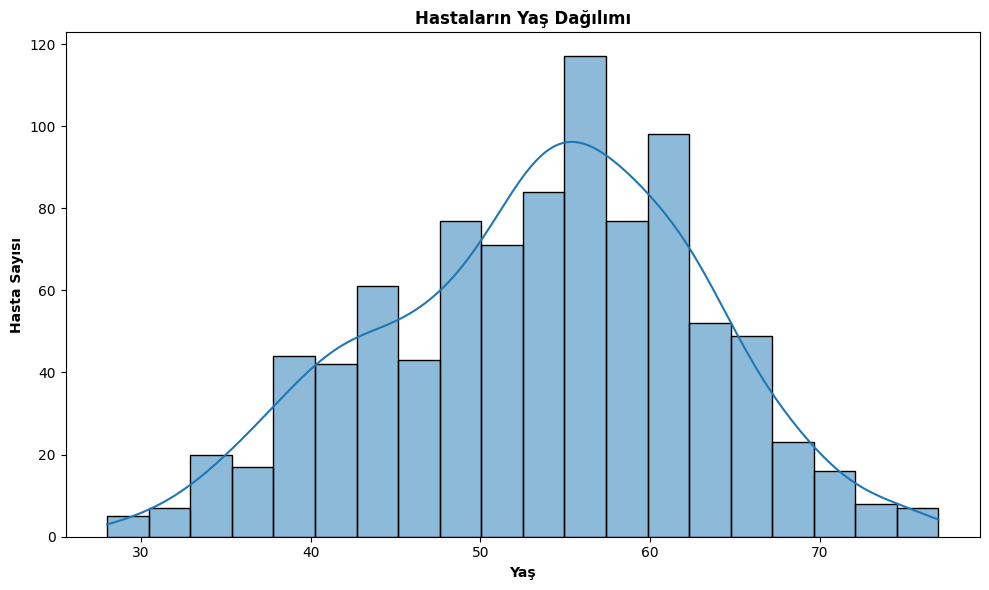

In [168]:
plt.figure(figsize=(10,6))
sns.histplot(p3heart["yas_orj"], bins=20, kde=True)
plt.title("Hastaların Yaş Dağılımı", fontweight="bold")
plt.xlabel("Yaş", fontweight="bold")
plt.ylabel("Hasta Sayısı", fontweight="bold")
plt.tight_layout()
plt.show()

Hangi yaşlarda hastalığın arttığını bu grafik ile görebiliyoruz.

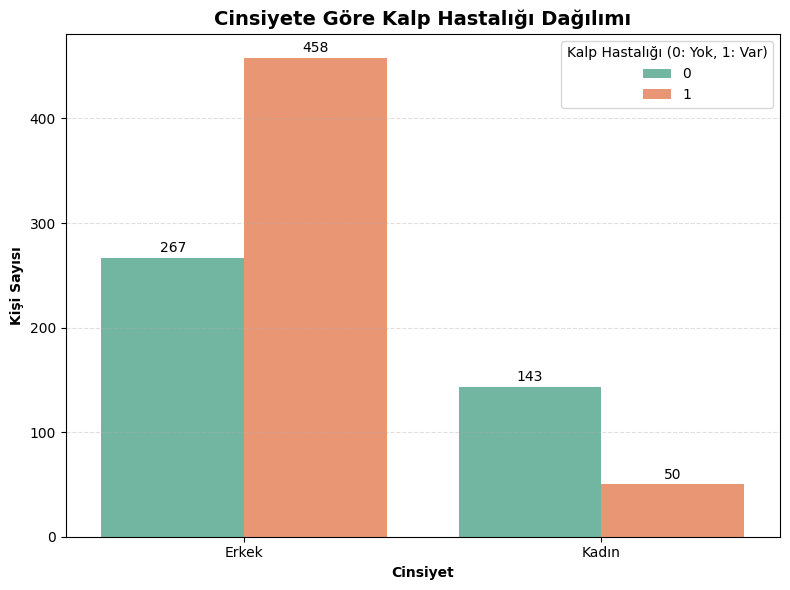

In [169]:
p3heart['cinsiyet_etiket'] = p3heart['cinsiyet'].map({0: 'Kadın', 1: 'Erkek'})

plt.figure(figsize=(8,6))
grafik = sns.countplot(x="cinsiyet_etiket", hue="kalp_hastaligi", data=p3heart, palette="Set2")
plt.title("Cinsiyete Göre Kalp Hastalığı Dağılımı", fontweight="bold", fontsize=14)
plt.xlabel("Cinsiyet", fontweight="bold")
plt.ylabel("Kişi Sayısı", fontweight="bold")

for container in grafik.containers:
    grafik.bar_label(container, fmt="%d", label_type="edge", padding=2)

plt.legend(title="Kalp Hastalığı (0: Yok, 1: Var)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Bu grafikte kadınlarda mı erkeklerde mi daha çok kalp hastalığı var onu görebiliyorum. Renk farkıyla hasta olanları hemen ayırabiliyorum. Erkeklerde hastalık daha fazla nerdeyse iki katı fark var.

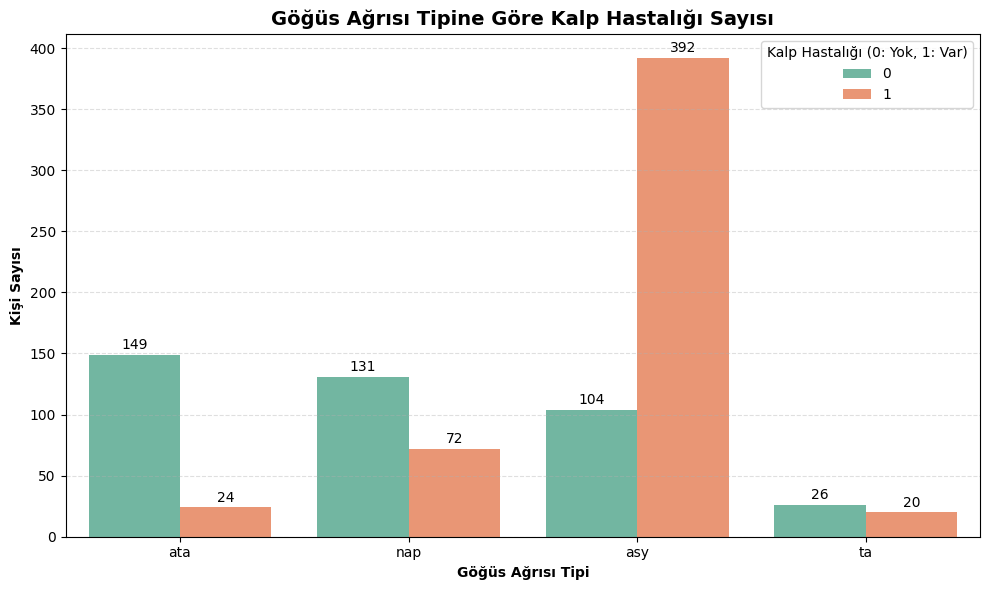

In [ ]:
plt.figure(figsize=(10,6))
grafik = sns.countplot(x="gogus_agrisi_tipi", hue="kalp_hastaligi", data=p3heart, palette="Set2")
plt.title("Göğüs Ağrısı Tipine Göre Kalp Hastalığı Sayısı", fontweight="bold", fontsize=14)
plt.xlabel("Göğüs Ağrısı Tipi", fontweight="bold")
plt.ylabel("Kişi Sayısı", fontweight="bold")

for container in grafik.containers:
    grafik.bar_label(container, fmt="%d", label_type="edge", padding=2)

plt.legend(title="Kalp Hastalığı (0: Yok, 1: Var)")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Ata eforla gelen ağrıyı gösteriyor yani fiziksel aktiviteyle oluşan göğüs ağrısı. Nap normalden sapma olmayan ama yine de kalp kökenli olabilecek ağrılar. Asy sessiz yani hiç ağrı hissetmeyen ama kalbi risk altında olan kişiler. Ta ise egzersiz dışında oluşan ama yine de kalp kaynaklı olabilecek ağrılar demek. TA en tehlikeli, ASY sinsidir, ATA tuhaf, NAP sıradan.

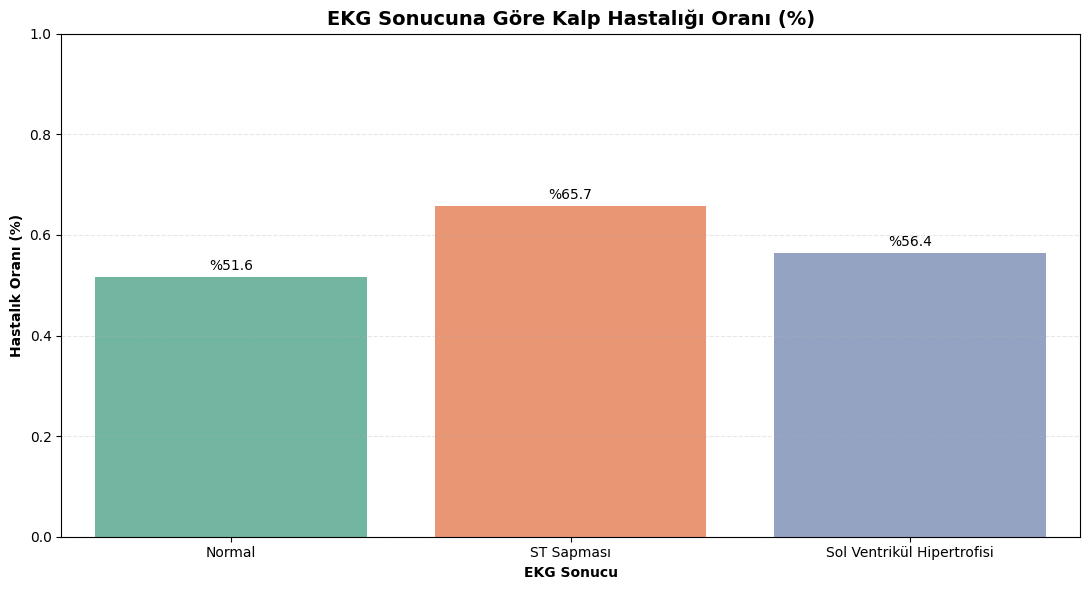

In [ ]:
p3heart['ekg_sonucu_aciklama'] = p3heart['ekg_sonucu'].map({
    'normal': 'Normal',
    'lvh': 'Sol Ventrikül Hipertrofisi',
    'st': 'ST Sapması'})

plt.figure(figsize=(11,6))
grafik = sns.barplot(
    x='ekg_sonucu_aciklama',
    y='kalp_hastaligi',
    data=p3heart,
    estimator=np.mean,
    palette='Set2',
    errorbar=None)

plt.title("EKG Sonucuna Göre Kalp Hastalığı Oranı (%)", fontweight="bold", fontsize=14)
plt.xlabel("EKG Sonucu", fontweight="bold")
plt.ylabel("Hastalık Oranı (%)", fontweight="bold")
plt.ylim(0, 1)

for bar in grafik.containers:
    grafik.bar_label(bar, labels=[f"%{v.get_height()*100:.1f}" for v in bar], padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Bu grafikte üç EKG sonucu grubunu karşılaştırıyoruz: Normal EKG çıkanların %51’inde hastalık var, sol ventrikül hipertrofisi olanlarda bu oran %55’e çıkıyor, ST segment sapması görülenlerde ise %66’ya kadar yükseliyor; yani ST sapması, kalp hastalığıyla en güçlü ilişkiyi gösteriyor.

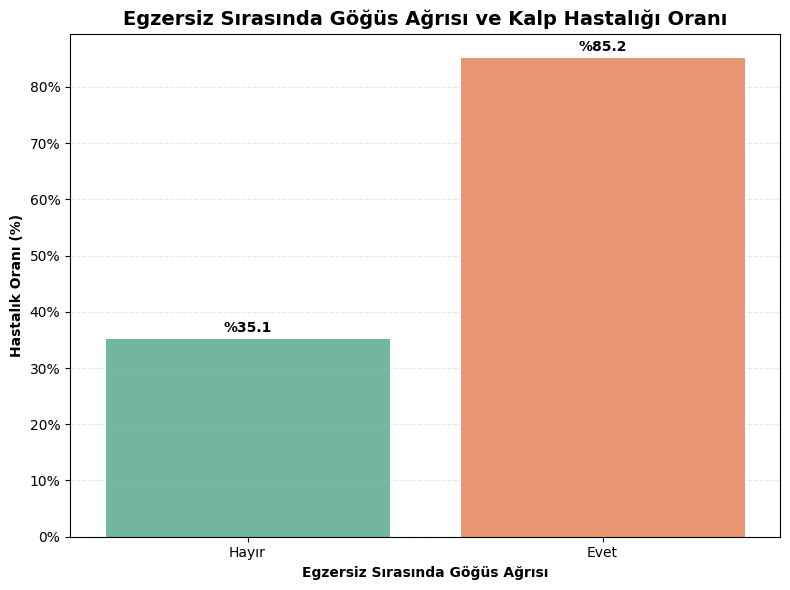

In [195]:
p3heart["gogus_agrisi_durumu"] = p3heart["gogus_agrisi"].map({0: "Hayır", 1: "Evet"})
plt.figure(figsize=(8, 6))
grafik = sns.barplot(
    x="gogus_agrisi_durumu",
    y="kalp_hastaligi",
    data=p3heart,
    estimator=np.mean,
    palette="Set2",
    errorbar=None
)

plt.title("Egzersiz Sırasında Göğüs Ağrısı ve Kalp Hastalığı Oranı", fontweight="bold", fontsize=14)
plt.xlabel("Egzersiz Sırasında Göğüs Ağrısı", fontweight="bold")
plt.ylabel("Hastalık Oranı (%)", fontweight="bold")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

for bar in grafik.containers:
    grafik.bar_label(
        bar,
        labels=[f"%{v.get_height()*100:.1f}" for v in bar],
        padding=3,
        fontweight="bold"
    )

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Egzersiz yaparken göğüs ağrısı hissedenlerin %85'i garanti hasta. Egzersiz yaparken göğüs ağrısı hissetmeyenlerin de %35'i hasta. Yani iki şekilde de hastalık maalesef ki yüksek oranlı var.

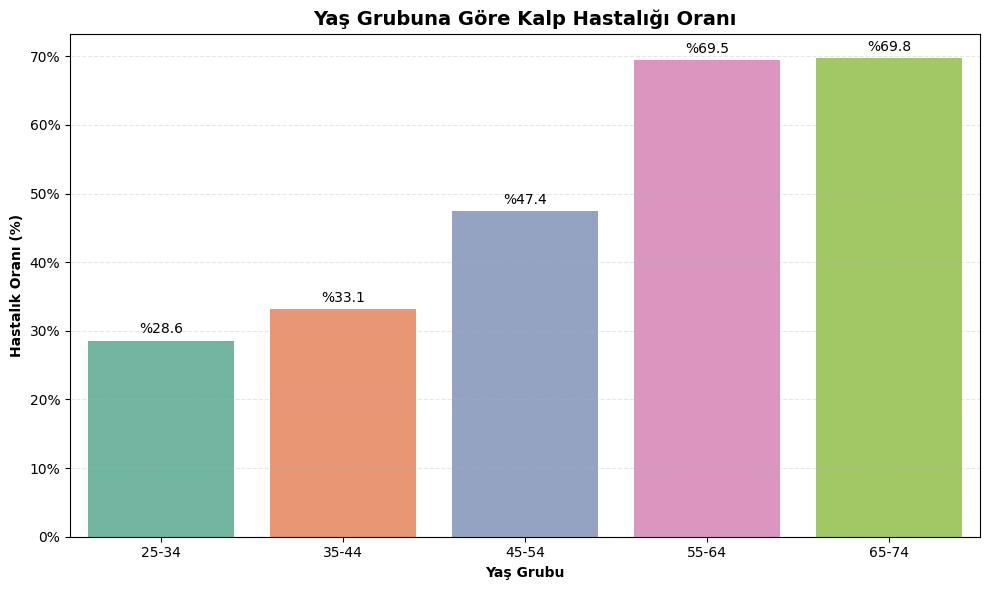

In [173]:
p3heart['yas_grubu'] = pd.cut(
    p3heart['yas_orj'],
    bins=[25, 35, 45, 55, 65, 75],
    labels=["25-34", "35-44", "45-54", "55-64", "65-74"],
    right=False
)

plt.figure(figsize=(10,6))
grafik = sns.barplot(
    x='yas_grubu',
    y='kalp_hastaligi',
    data=p3heart,
    estimator=np.mean,
    palette='Set2',
    errorbar=None
)
plt.title("Yaş Grubuna Göre Kalp Hastalığı Oranı", fontweight="bold", fontsize=14)
plt.xlabel("Yaş Grubu", fontweight="bold")
plt.ylabel("Hastalık Oranı (%)", fontweight="bold")
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

for bar in grafik.containers:
    grafik.bar_label(bar, labels=[f"%{v.get_height()*100:.1f}" for v in bar], padding=3)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Bu grafikte yaş ilerledikçe kalp hastalığı oranı düzenli biçimde artıyor. Özellikle 55-74 yaş arasındaki insanların %69'u hasta. 25 ve 34 yaş arasındaki insanların %28'i hasta. Grafikteki çıkarıma göre yaş, kalp hastalığı açısından güçlü bir risk belirleyicidir.

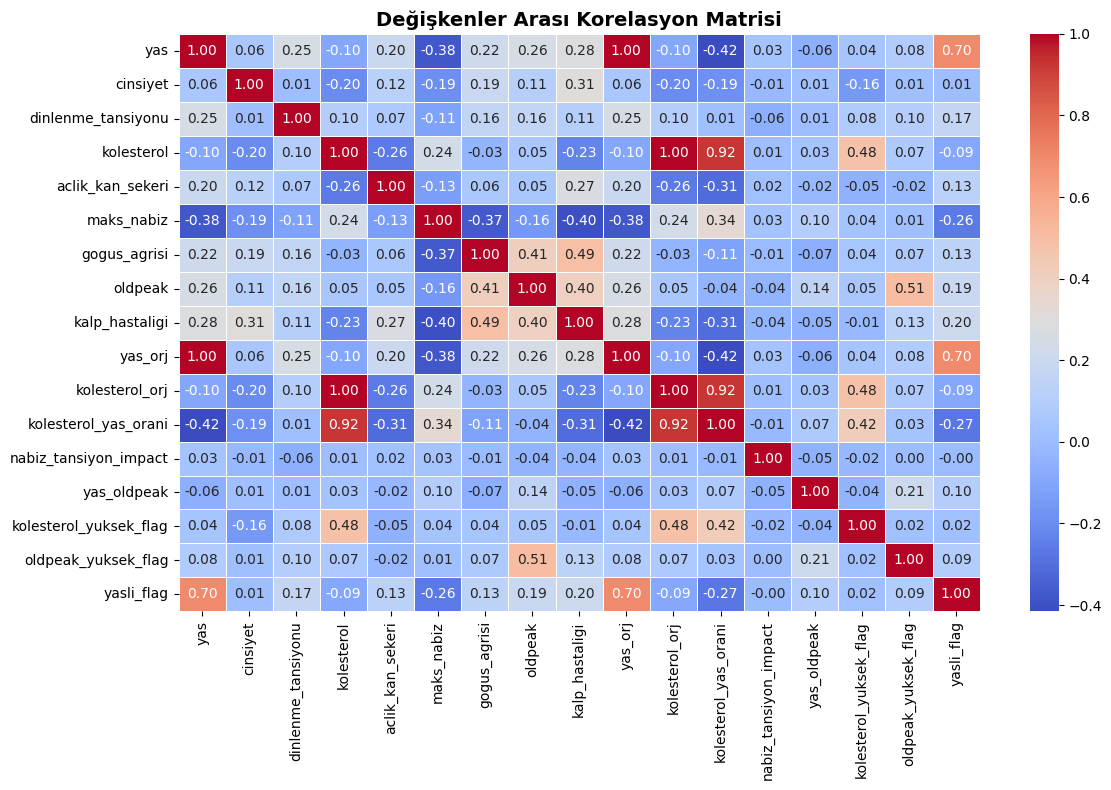

In [174]:
plt.figure(figsize=(12,8))
corr = p3heart.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Değişkenler Arası Korelasyon Matrisi", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

Bu korelasyon maddesinde kalp hastalığı ile en güçlü ilişki %49 ile oldpeak değişkenine ait yani ST segment sapması arttıkça hastalık riski de artıyor. Yaşla hastalık arasında %28’lik pozitif, maksimum nabızla ise %27’lik negatif ilişki var; yaşlı bireylerde hastalık riski artarken, nabız düşüyor. Kolesterol değişkeni ise kalp hastalığıyla anlamlı bir korelasyon göstermiyor.

MODEL EĞİTİMİ

In [ ]:
X = p3heart.drop("kalp_hastaligi", axis=1)
y = p3heart["kalp_hastaligi"]

Kalp hastalığı sonucu tahmin edeceğimiz için “kalp_hastaligi” bizim hedef sütunumuz oldu. Diğer tüm sütunlar bu sonucu tahmin etmek için kullanılıyor.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_encoded = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [183]:
X_train.dtypes.value_counts()

bool       21
float64     8
int64       8
Name: count, dtype: int64

Bu kodda önce verideki yazı türündeki sütunları otomatik olarak 0 ve 1 gibi sayılara çevirdik. Sonra veriyi %80 eğitim, %20 test olarak ayırdık. Son olarak da Logistic Regression modelini oluşturduk ve eğitim verisiyle modeli eğittik, yani model artık veriden öğrenmiş oldu. Burada get_dummies() kullanımı not alınabilir.

In [ ]:
y_pred = log_model.predict(X_test)
print("İlk 10 tahmin:", y_pred[:10])

İlk 10 tahmin: [0 0 1 1 0 1 1 0 1 1]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
importance_df = pd.DataFrame({
    "Değişken": X_encoded.columns,
    "Önem": rf_model.feature_importances_
}).sort_values("Önem", ascending=False).head(5).reset_index(drop=True)

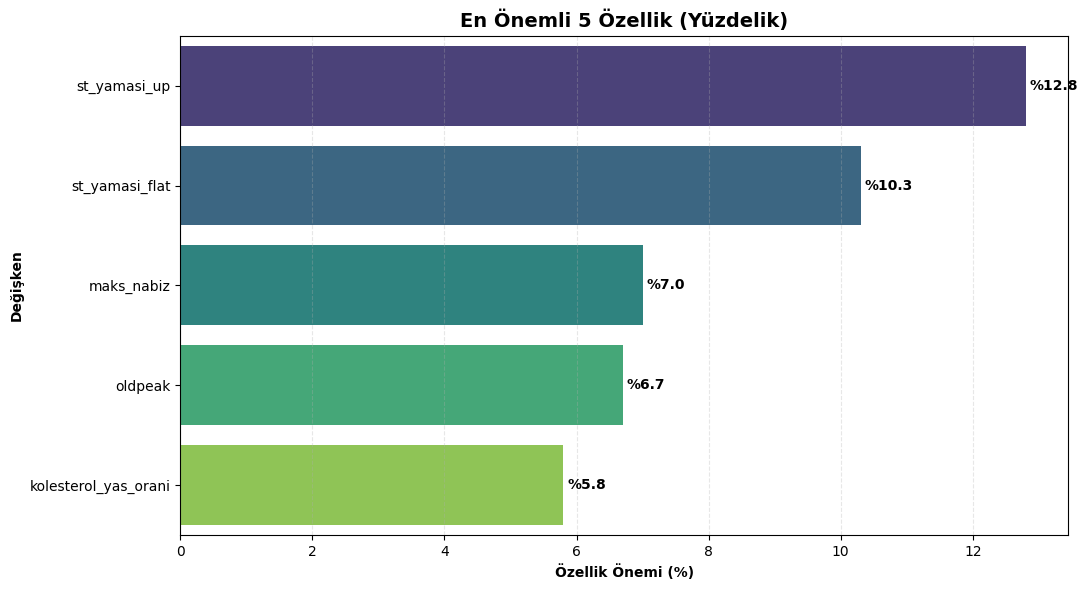

In [175]:
importance_df["Önem (%)"] = (importance_df["Önem"] * 100).round(1)

plt.figure(figsize=(11,6))
grafik = sns.barplot(
    x="Önem (%)",
    y="Değişken",
    data=importance_df,
    palette="viridis"
)

plt.title("En Önemli 5 Özellik (Yüzdelik)", fontweight="bold", fontsize=14)
plt.xlabel("Özellik Önemi (%)", fontweight="bold")
plt.ylabel("Değişken", fontweight="bold")

for bar in grafik.containers:
    grafik.bar_label(bar, labels=[f"%{v.get_width():.1f}" for v in bar], padding=3, fontweight="bold")

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

Bu grafikte modelin en çok dikkat ettiği değişken ST segment eğimi olmuş; yani EKG sonucunda çıkan çizginin yukarı mı gittiği, düz mü olduğu. ST_yamasi_up dediğimiz yukarı eğimli çizgi genelde normal kabul edilirken, ST_yamasi_flat yani düz çizgi kalp damarlarında oksijen yetersizliği ya da tıkanıklık gibi sorunların işareti olabilir. Model için bu sinyal çok önemli çünkü kalpte bir problem olup olmadığını doğrudan gösteriyor. Yukarı eğimli olan %12.9 önem taşırken, düz olan da %10.3 ile ikinci sırada yer alıyor. Yani sadece bu iki EKG sinyali modelin verdiği kararların yaklaşık %23’ünü etkiliyor. Bu da demek oluyor ki, ST segmenti verisi, kalp hastalığını tahmin etmekte modelin en çok güvendiği bilgi kaynaklarından biri. Nabız, oldpeak ve kolesterol yaş oranı gibi diğer değişkenler de etkili ama EKG verisi açık ara önde.

In [188]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def get_scores(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

scores = [
    get_scores("Logistic Regression", y_test, log_model.predict(X_test)),
    get_scores("Random Forest", y_test, rf_model.predict(X_test)),
    get_scores("KNN", y_test, knn_model.predict(X_test))
]

skor_df = pd.DataFrame(scores)
skor_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.864130,0.894231,0.869159,0.881517
1,Random Forest,0.853261,0.870370,0.878505,0.874419
2,KNN,0.684783,0.733333,0.719626,0.726415


Bu tabloda 3 farklı modelin doğruluk oranlarını karşılaştırıyoruz. En yüksek başarı Logistic Regression modelinde. Accuracy’si %86, f1score'u da %88 civarında, yani en dengeli sonuçları o veriyor. Random Forest da çok yakın (%85 civarı doğruluk, %87 f1), ama precision ve recall dengesi biraz daha dengesiz. KNN en kötü model doğruluğu sadece %68, yani bu veri seti için fazla zayıf kalmış.

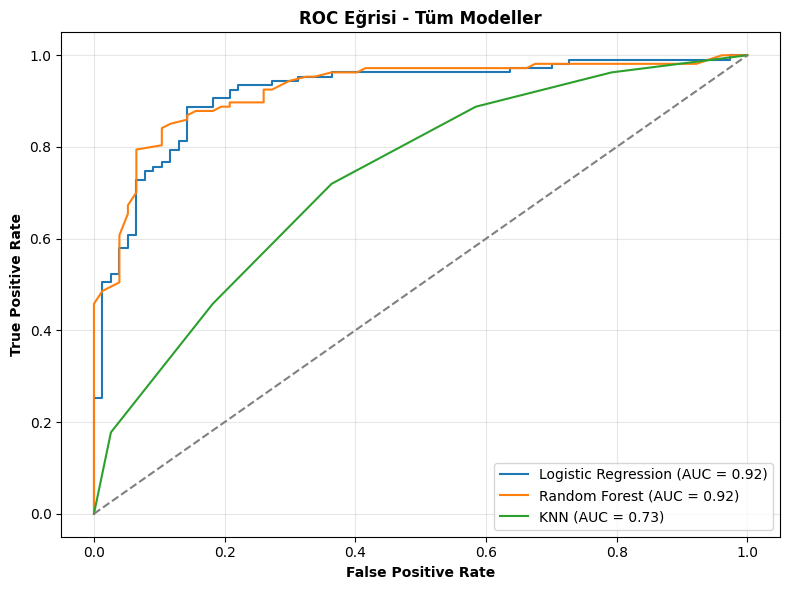

In [191]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
y_probs_log = log_model.predict_proba(X_test)[:, 1]
y_probs_rf  = rf_model.predict_proba(X_test)[:, 1]
y_probs_knn = knn_model.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_probs_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probs_knn)

auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate", fontweight="bold")
plt.ylabel("True Positive Rate", fontweight="bold")
plt.title("ROC Eğrisi - Tüm Modeller", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

AUC değeri 1'e ne kadar yakınsa o kadar iyi. Logistic Regression ve Random Forest %92 başarı oranı ile çok iyi, KNN ise %73'lük başarı ile sınıfta kaldı.

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(log_model, X_encoded, y, cv=5, scoring="accuracy")

print("Doğruluk skorları (her fold):", cv_scores)
print("Ortalama doğruluk:", round(cv_scores.mean(), 4))
print("Standart sapma:", round(cv_scores.std(), 4))

Doğruluk skorları (her fold): [0.83695652 0.8423913  0.82065217 0.84699454 0.75956284]
Ortalama doğruluk: 0.8213
Standart sapma: 0.0321


5 katlı çapraz doğrulama(cros validation) yapıldı. Daha önce %92 doğruluk görmüştük ama bu sadece bir test grubundaydı. Cross validation ise veriyi 5 parçaya ayırıp modelin her parçada nasıl performans gösterdiğini test ediyor. Ortalamada %82.13 çıkması, modelin tüm veride ortalama bu kadar başarılı olduğunu gösteriyor. Bu değer daha güvenilir.